# Реализация линейной регрессии своими руками

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from algorithms.linear_regression import LinearRegression

In [2]:
# Загрузим датасет
X, y = fetch_california_housing(download_if_missing=True, return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True)
X_train.shape

(15480, 8)

In [3]:
# Нормализуем данные в датасете
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# Создаем экземпляр класса линейной регрессии
linear_regression = LinearRegression(lr=1e-5)

In [5]:
# Обучаем линейную регрессию
linear_regression.fit(X_train_scaled, y_train)

In [6]:
# Прогоняем тестовые данные через модель
predicted = []

for x, y in zip(X_test_scaled, y_test):
    y_pred = linear_regression.predict(x)
    predicted.append(y_pred)
    
predicted = np.array(predicted)

In [7]:
# Cчитаем метрики
mse = mean_squared_error(y_test, predicted)
mae = mean_absolute_error(y_test, predicted)
r2 = r2_score(y_test, predicted)

print(f"r2: {r2}")
print(f"mae: {mae}")
print(f"mse: {mse}")

r2: 0.6142693846716412
mae: 0.5326714383971803
mse: 0.5270525627196065


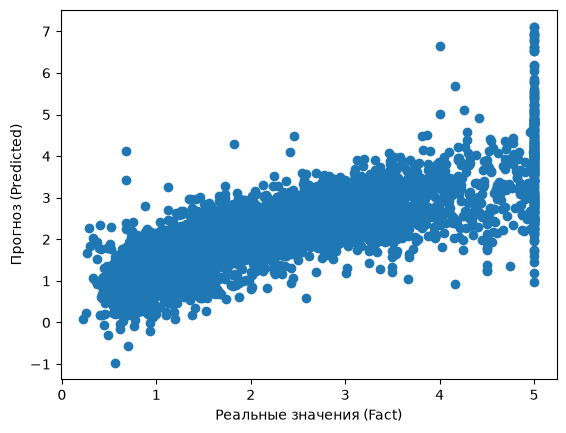

In [8]:
# Построим графики

plt.scatter(y_test, predicted)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Реальные значения (Fact)')
plt.ylabel('Прогноз (Predicted)')
plt.show()